In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('seaborn-v0_8')
# from moc.metrics.distribution_metrics import pce, calculate_PIT
# import torch

from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal

In [3]:
def build_multivariate_normal(d, sigma2, tau, mean):
    indices = np.arange(d)
    diff = np.abs(indices[:, None] - indices[None, :])
    covariance_matrix = sigma2 * np.exp(-diff / tau)
    dist = multivariate_normal(mean=mean, cov=covariance_matrix)
    return covariance_matrix, dist

In [5]:
d = 2
sigma2 = 1.0
tau = 1.0
overmean1 = np.ones(d) * 0.5
overmean2 = np.ones(d) * 3.0
true_mean = np.zeros(d)
true_covariance, true_dist = build_multivariate_normal(d, sigma2, tau, true_mean)
overmean_cov1, overmean_dist1 = build_multivariate_normal(d, sigma2, tau, overmean1)
overmean_cov2, overmean_dist2 = build_multivariate_normal(d, sigma2, tau, overmean2)
overvar_cov1, overvar_dist1 = build_multivariate_normal(d, 1.25, tau, true_mean)
overvar_cov2, overvar_dist2 = build_multivariate_normal(d, 5.0, tau, true_mean)

In [ ]:
# undermean = torch.ones(d) * - 0.5

# undermean_dist = build_multivariate_normal(d, sigma2, tau, undermean)

# undercorr_dist = build_multivariate_normal(d, sigma2, 0.5, mean)
# overcorr_dist = build_multivariate_normal(d, sigma2, 2, mean)


In [6]:
#Sampling true targets
N = 1000
y_true = true_dist.rvs(size=N, random_state=42) # true targets

In [7]:
#let's apply PCA on y_true
eigvals, eigvecs = np.linalg.eigh(true_covariance)
idx = np.argsort(eigvals)[::-1] #sorting in descending order

eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("True Eigenvalues:", eigvals)
print("True Eigenvectors:\n", eigvecs)

True Eigenvalues: [1.368 0.632]
True Eigenvectors:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]


In [7]:
def calculate_pit(dist, y, n_samples, prerank, eigvecs = None, seed = 42):
    rng = np.random.default_rng(seed)
    samples = dist.rvs(size=(n_samples,), random_state=rng)
    pits = []
    if prerank == "marginal":
        for dim in range(d):
            samples_proj = samples[:,dim] 
            y_proj = y[:,dim]
            ranks = np.searchsorted(np.sort(samples_proj), y_proj, side="right")
            cdfs = ranks / len(samples_proj)
            pits.append(cdfs)
    elif prerank == "mean":
        y_proj, samples_proj = y.mean(dim=-1), samples.mean(dim=-1)
        ranks = np.searchsorted(np.sort(samples_proj), y_proj, side="right")
        cdfs = ranks / len(samples_proj)
        pits.append(cdfs)
    elif prerank == "pca":
        if eigvecs is None:
            pca = PCA(n_components=None)
            pca.fit(samples)
            y_proj, samples_proj = pca.transform(y), pca.transform(samples)
        else:
            y_proj = y @ eigvecs
            samples_proj = samples @ eigvecs
        for dim in range(d):
            samples = samples_proj[:,dim] 
            y = y_proj[:,dim] 
            ranks = np.searchsorted(np.sort(samples), y, side="right")
            cdfs = ranks / len(samples)
            pits.append(cdfs)
    pits = np.stack(pits, axis = 1)
    return pits

In [13]:
def plot_pits(pits, prerank, dist = "true"):
    n_dims = pits.shape[1]

    if n_dims > 1:
        # choose grid: max 5 columns, rows adjust automatically
        n_cols = min(5, n_dims)
        n_rows = int(np.ceil(n_dims / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        axes = np.atleast_1d(axes).flatten()

        for i in range(n_dims):
            axes[i].hist(pits[:, i], bins=20, density=True,
                         alpha=0.7, color='skyblue', zorder=3)
            if prerank == "pca":
                axes[i].set_title(fr"$Z_{{{i+1}}}$")
            else:
                axes[i].set_title(fr"$y_{{{i+1}}}$")
            axes[i].set_xlabel("PIT value")
            axes[i].set_ylabel("Density")
            axes[i].grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

        # hide any unused axes
        for j in range(n_dims, len(axes)):
            axes[j].set_visible(False)

    else:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.hist(pits, bins=10, density=True,
                alpha=0.7, color='skyblue', zorder=3)
        ax.set_xlabel("PIT value")
        ax.set_ylabel("Density")
        ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    fig.suptitle(f"{prerank} PIT Histograms from {dist} Dist.", fontsize=12)
    plt.tight_layout()
    plt.show()

    return fig

In [9]:
#calculating true PITs using the samples from true distribution and using true eigenvectors
true_pits = calculate_pit(true_dist, y_true, n_samples = 1000, prerank = "pca", seed = 42)
overmean1_pits = calculate_pit(overmean_dist1, y_true, n_samples = 1000, prerank = "pca", seed = 42)
overmean2_pits = calculate_pit(overmean_dist2, y_true, n_samples = 1000, prerank = "pca", seed = 42)
overvar1_pits = calculate_pit(overvar_dist1, y_true, n_samples = 1000, prerank = "pca", seed = 42)
overvar2_pits = calculate_pit(overvar_dist2, y_true, n_samples = 1000, prerank = "pca", seed = 42)

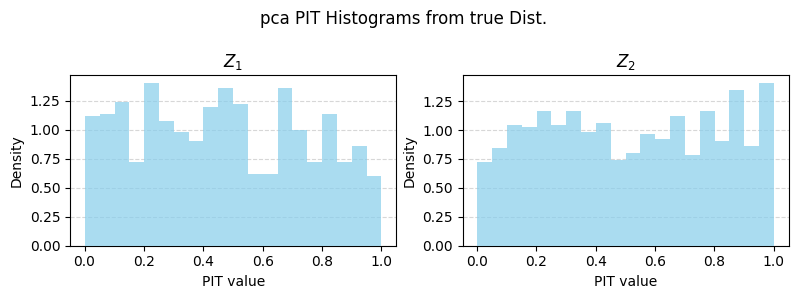

In [14]:
fig = plot_pits(true_pits, prerank = "pca", dist = "true")
# fig.savefig("figures/true_pits.png", dpi = 400, bbox_inches = "tight")

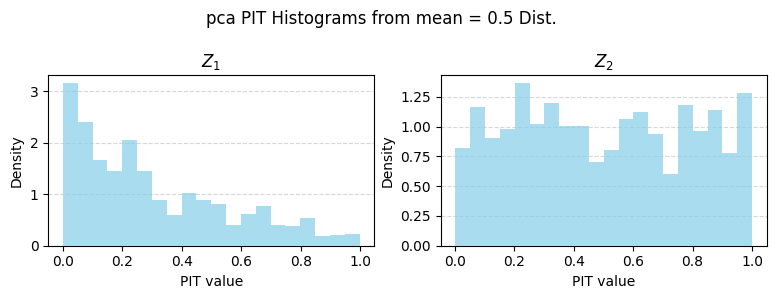

In [15]:
fig = plot_pits(overmean1_pits, prerank = "pca", dist = "mean = 0.5")
fig.savefig("figures/overmean1_pits_estimatedPC.png", dpi = 400, bbox_inches = "tight")

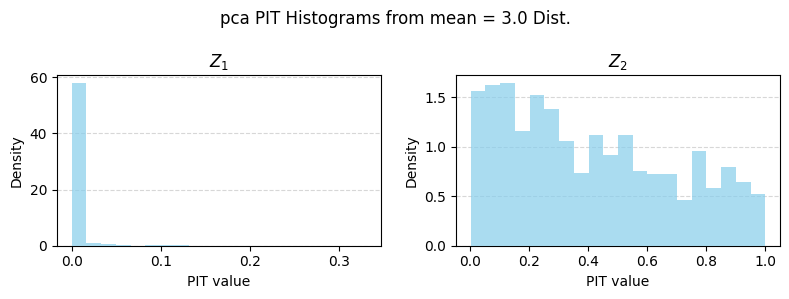

In [16]:
fig = plot_pits(overmean2_pits, prerank = "pca", dist = "mean = 3.0")
fig.savefig("figures/overmean2_pits_estimatedPC.png", dpi = 400, bbox_inches = "tight")

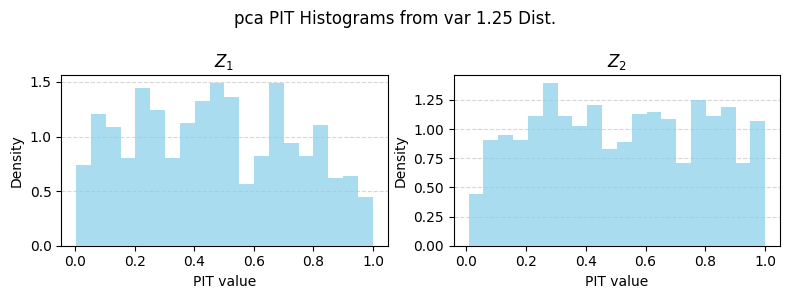

In [17]:
fig = plot_pits(overvar1_pits, prerank = "pca", dist = "var 1.25")
fig.savefig("figures/overvar1_pits_estimatedPC.png", dpi = 400, bbox_inches = "tight")

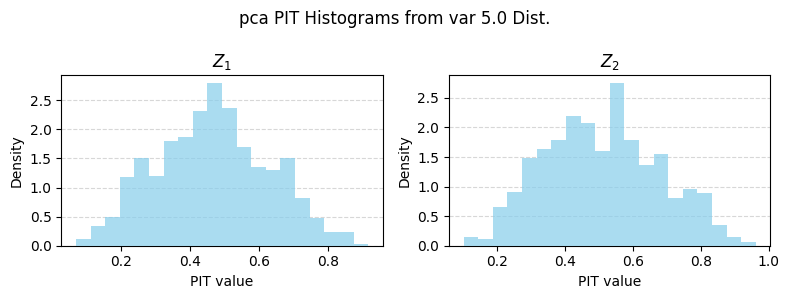

In [18]:
fig = plot_pits(overvar2_pits, prerank = "pca", dist = "var 5.0")
fig.savefig("figures/overvar2_pits_estimatedPC.png", dpi = 400, bbox_inches = "tight")

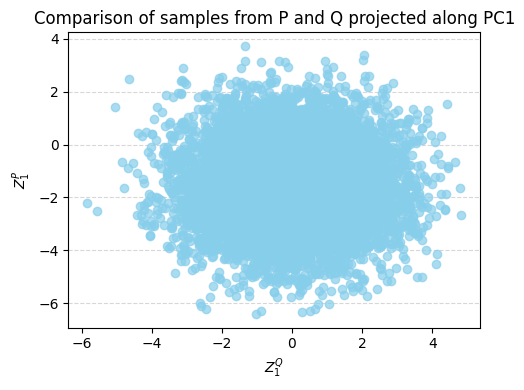

In [23]:
# Let's look at the first dimension of z_q and z_p
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(samples_proj[:,0], y_proj[:,0], alpha=0.7, color='skyblue', zorder=3)
ax.set_title("Comparison of samples from P and Q projected along PC1", fontsize=12)
ax.set_xlabel(fr"$Z_{1}^{{Q}}$")
ax.set_ylabel(fr"$Z_{1}^{{P}}$")
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

plt.tight_layout()
fig.savefig("figures/z_p_against_z_q.png", dpi=400, bbox_inches="tight")
plt.show()

In [24]:
# Apply moment correction to Z_1^Q so that it matches Z_1^P
mu_p, std_p = y_proj[:,0].mean(), y_proj[:,0].std(ddof=0)
mu_q, std_q = samples_proj[:,0].mean(), samples_proj[:,0].std(ddof=0)

Z1_q_cal = (samples_proj[:,0] - mu_q) / std_q * std_p + mu_p
print(mu_p, std_p)
print(Z1_q_cal.mean(), Z1_q_cal.std(ddof=0))

-1.4938818 1.4302377
-1.4938817 1.4302377


In [26]:
Z_q_new = samples_proj.copy()
Z_q_new[:,0] = Z1_q_cal
y_hat_q = (Z_q_new @ V) + mu_q

In [31]:
y_p.shape

torch.Size([10000, 10])

In [36]:
# Now, using this new y_hat_q where the first principal component has been moment-corrected, let's calculate PIT values again
prerank = "pca"
pits = []
if prerank == "marginal":
    for dim in range(d):
        samples_proj = y_hat_q[:,dim] 
        y_proj = y_p[:,dim].numpy() 
        ranks = np.searchsorted(np.sort(samples_proj), y_proj, side="right")
        cdfs = ranks / len(samples_proj)
        pits.append(cdfs)
elif prerank == "mean":
    y_proj, samples_proj = y_p.mean(dim=-1).numpy(), y_hat_q.mean(axis=-1)
    ranks = np.searchsorted(np.sort(samples_proj), y_proj, side="right")
    cdfs = ranks / len(samples_proj)
    pits.append(cdfs)
elif prerank == "pca":
    pca = PCA(n_components=None)
    pca.fit(y_hat_q)
    y_proj, samples_proj = pca.transform(y_p.numpy()), pca.transform(y_hat_q)
    for dim in range(d):
        samples = samples_proj[:,dim] 
        y = y_proj[:,dim] 
        ranks = np.searchsorted(np.sort(samples), y, side="right")
        cdfs = ranks / len(samples)
        pits.append(cdfs)
pits = np.stack(pits, axis = 1)

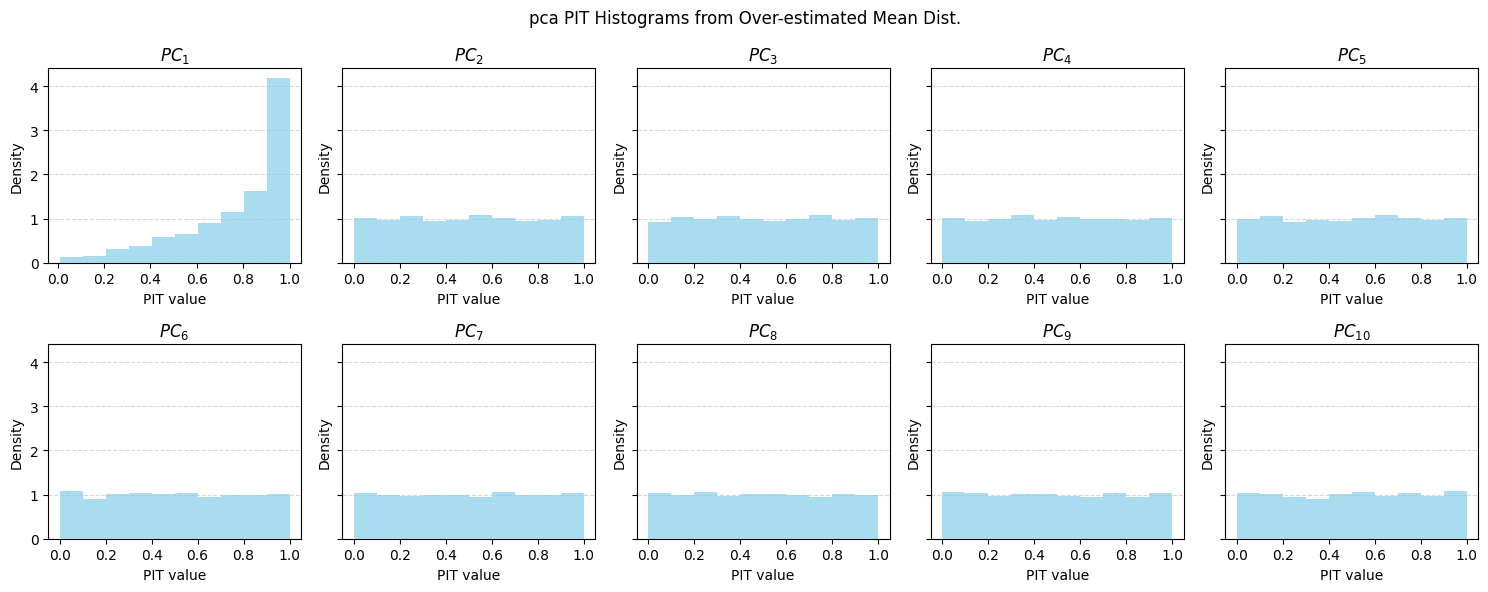

In [37]:
if pits.shape[1] > 1:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharey=True)
    axes = axes.flatten()

    for i in range(10):
        axes[i].hist(pits[:, i], bins=10, density=True,
                    alpha=0.7, color='skyblue', zorder=3)
        axes[i].set_title(fr"$PC_{{{i+1}}}$")
        axes[i].set_xlabel("PIT value")
        axes[i].set_ylabel("Density")
        axes[i].grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
else: 
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(pits, bins=10, density=True,
            alpha=0.7, color='skyblue', zorder=3)
    ax.set_xlabel("PIT value")
    ax.set_ylabel("Density")
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

fig.suptitle(f"{prerank} PIT Histograms from Over-estimated Mean Dist.", fontsize=12)
plt.tight_layout()
fig.savefig(f"figures/{prerank}_pit_from_overmean_dist_pc_correction.png", dpi=400, bbox_inches="tight")
plt.show()